# Upper Tennesse Storm Types

- Fronts (FRONT)
- Extratropical Cyclones (ETC)
- Atmospheric Rivers (AR)
- Tropical Cyclones (TC)
- North American Monsoon (NAM)

Alshehri et al (2024)
https://journals.ametsoc.org/view/journals/hydr/25/12/JHM-D-24-0024.1.xml

In [1]:
import os
import pandas as pd
import geopandas as gpd

In [2]:
ghcnd_metadata_file = "/workspaces/stormhub/data/0_source/ghcnd/ghcnd_stations.parquet"
ghcnd_database_file = "/workspaces/stormhub/data/0_source/ghcnd/all_stations.parquet"
transposition_file = "/workspaces/stormhub/data/0_source/0601_SLAMSIM2/0601_SLAMSIM2/TD.AORC.16km.0601.annual.mean.20.shp"
huc4_file = "/workspaces/stormhub/data/0_source/huc04/upper_tn.shp"

In [3]:
stations_gdf = gpd.read_parquet(ghcnd_metadata_file)
stations_gdf

,SITE_ID,LATITUDE,LONGITUDE,ELEVATION,SITE_NAME,geometry
0,ACW00011604,17.1167,-61.7833,10.1,ST JOHNS COOLIDGE FLD,POINT (-61.7833 17.1167)
1,ACW00011647,17.1333,-61.7833,19.2,ST JOHNS,POINT (-61.7833 17.1333)
2,AE000041196,25.3330,55.5170,34.0,SHARJAH INTER. AIRP,POINT (55.517 25.333)
3,AEM00041194,25.2550,55.3640,10.4,DUBAI INTL,POINT (55.364 25.255)
4,AEM00041217,24.4330,54.6510,26.8,ABU DHABI INTL,POINT (54.651 24.433)
...,...,...,...,...,...,...
129652,ZI000067969,21.0500,29.3670,861.0,WEST NICHOLSON,POINT (29.367 21.05)
129653,ZI000067975,20.0670,30.8670,1095.0,MASVINGO,POINT (30.867 20.067)
129654,ZI000067977,21.0170,31.5830,430.0,BUFFALO RANGE,POINT (31.583 21.017)
129655,ZI000067983,20.2000,32.6160,1132.0,CHIPINGE,POINT (32.616 20.2)


In [4]:
transposition_gdf = gpd.read_file(transposition_file)
transposition_gdf = transposition_gdf.to_crs(stations_gdf.crs)
transposition_gdf

ERROR 1: PROJ: proj_create_from_database: Open of /opt/conda/envs/stormhub-base/share/proj failed


,area_mult,area,area_km2,area_ratio,domain_gri,watershed_,ds1_points,ds2_points,ds1_domain,ds2_domain,valid_tran,geometry
0,20.0,90.493462,896257.250699,20.011145,5039.0,308.0,1088,1088,5932,6865,5039,"POLYGON ((-91.21822 40.46251, -90.54898 40.462..."


In [5]:
huc4_gdf = gpd.read_file(huc4_file)
huc4_gdf = huc4_gdf.to_crs(stations_gdf.crs)
huc4_gdf

,areaacres,areasqkm,states,huc4,name,globalid,geometry
0,11067332.0,44787.94,"GA,KY,NC,SC,TN,VA,WV",0601,Upper Tennessee,{d090e66a-a52c-4420-96b3-665e692f4f65},"POLYGON ((-81.72338 37.24047, -81.72291 37.240..."


In [6]:
# find stations within transposition area
merged_stations_gdf = gpd.sjoin(stations_gdf, transposition_gdf, how="inner", predicate="intersects")
merged_stations_gdf

,SITE_ID,LATITUDE,LONGITUDE,ELEVATION,SITE_NAME,geometry,index_right,area_mult,area,area_km2,area_ratio,domain_gri,watershed_,ds1_points,ds2_points,ds1_domain,ds2_domain,valid_tran
64699,US1GABN0001,34.4821,-83.5293,403.9,BALDWIN 1.4 ESE,POINT (-83.5293 34.4821),0,20.0,90.493462,896257.250699,20.011145,5039.0,308.0,1088,1088,5932,6865,5039
64700,US1GABN0002,34.2541,-83.3819,216.4,COMMERCE 5.6 NE,POINT (-83.3819 34.2541),0,20.0,90.493462,896257.250699,20.011145,5039.0,308.0,1088,1088,5932,6865,5039
64701,US1GABN0005,34.3950,-83.4502,298.1,HOMER 5.1 NNE,POINT (-83.4502 34.395),0,20.0,90.493462,896257.250699,20.011145,5039.0,308.0,1088,1088,5932,6865,5039
64724,US1GABW0001,34.0260,-83.8405,302.1,AUBURN 1.0 NNW,POINT (-83.8405 34.026),0,20.0,90.493462,896257.250699,20.011145,5039.0,308.0,1088,1088,5932,6865,5039
64725,US1GABW0004,34.0426,-83.6919,226.2,WINDER 3.9 NNE,POINT (-83.6919 34.0426),0,20.0,90.493462,896257.250699,20.011145,5039.0,308.0,1088,1088,5932,6865,5039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128648,USW00093986,34.9892,-99.0528,473.4,HOBART MUNI AP,POINT (-99.0528 34.9892),0,20.0,90.493462,896257.250699,20.011145,5039.0,308.0,1088,1088,5932,6865,5039
128651,USW00093989,39.9372,-91.1967,231.6,QUINCY RGNL AP,POINT (-91.1967 39.9372),0,20.0,90.493462,896257.250699,20.011145,5039.0,308.0,1088,1088,5932,6865,5039
128656,USW00093994,39.6833,-91.3333,163.1,HANNIBAL,POINT (-91.3333 39.6833),0,20.0,90.493462,896257.250699,20.011145,5039.0,308.0,1088,1088,5932,6865,5039
128657,USW00093995,38.3000,-94.3333,264.9,BUTLER,POINT (-94.3333 38.3),0,20.0,90.493462,896257.250699,20.011145,5039.0,308.0,1088,1088,5932,6865,5039


In [7]:
master_df = pd.read_parquet(ghcnd_database_file, filters=[("station", "in", merged_stations_gdf["SITE_ID"].tolist())])
master_df["cause_1"].fillna("Others", inplace=True)

/tmp/ipykernel_24883/3994891200.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  master_df["cause_1"].fillna("Others", inplace=True)


In [8]:
unique_stations = master_df.station.unique().tolist()
merged_stations_gdf = merged_stations_gdf[merged_stations_gdf["SITE_ID"].isin(unique_stations)]
merged_stations_gdf

,SITE_ID,LATITUDE,LONGITUDE,ELEVATION,SITE_NAME,geometry,index_right,area_mult,area,area_km2,area_ratio,domain_gri,watershed_,ds1_points,ds2_points,ds1_domain,ds2_domain,valid_tran
105162,USC00090603,34.3328,-84.4703,387.1,BALL GROUND,POINT (-84.4703 34.3328),0,20.0,90.493462,896257.250699,20.011145,5039.0,308.0,1088,1088,5932,6865,5039
105170,USC00090969,34.8544,-83.9444,594.1,BLAIRSVILLE EXP STN,POINT (-83.9444 34.8544),0,20.0,90.493462,896257.250699,20.011145,5039.0,308.0,1088,1088,5932,6865,5039
105195,USC00091585,34.2072,-84.5039,345.9,CANTON,POINT (-84.5039 34.2072),0,20.0,90.493462,896257.250699,20.011145,5039.0,308.0,1088,1088,5932,6865,5039
105197,USC00091619,34.3656,-83.2328,204.2,CARNESVILLE,POINT (-83.2328 34.3656),0,20.0,90.493462,896257.250699,20.011145,5039.0,308.0,1088,1088,5932,6865,5039
105213,USC00091982,34.8878,-83.3967,598.9,CLAYTON 1 SSW,POINT (-83.3967 34.8878),0,20.0,90.493462,896257.250699,20.011145,5039.0,308.0,1088,1088,5932,6865,5039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128588,USW00093822,39.8453,-89.6839,179.8,SPRINGFIELD ABRAHAM LINCO,POINT (-89.6839 39.8453),0,20.0,90.493462,896257.250699,20.011145,5039.0,308.0,1088,1088,5932,6865,5039
128611,USW00093846,34.4981,-82.7092,233.8,ANDERSON FAA AP,POINT (-82.7092 34.4981),0,20.0,90.493462,896257.250699,20.011145,5039.0,308.0,1088,1088,5932,6865,5039
128647,USW00093985,32.7817,-98.0603,287.1,MINERAL WELLS AP,POINT (-98.0603 32.7817),0,20.0,90.493462,896257.250699,20.011145,5039.0,308.0,1088,1088,5932,6865,5039
128648,USW00093986,34.9892,-99.0528,473.4,HOBART MUNI AP,POINT (-99.0528 34.9892),0,20.0,90.493462,896257.250699,20.011145,5039.0,308.0,1088,1088,5932,6865,5039


In [9]:
storm_types = {}
for station in unique_stations:
    subset = master_df[master_df["station"] == station].copy()
    counts = subset["cause_1"].value_counts()
    percents = (counts / counts.sum() * 100).round(2)
    storm_types[station] = {
        "counts": counts.to_dict(),
        "percent": percents.to_dict(),
    }
    print(f"Station {station} has {len(subset)} records and {len(counts)} storm types.")

Station USC00090603 has 23514 records and 4 storm types.
Station USC00090969 has 24877 records and 4 storm types.
Station USC00091585 has 23048 records and 4 storm types.
Station USC00091619 has 24328 records and 4 storm types.
Station USC00091982 has 24807 records and 4 storm types.
Station USC00092006 has 25162 records and 4 storm types.
Station USC00092283 has 25406 records and 4 storm types.
Station USC00092408 has 23903 records and 4 storm types.
Station USC00093060 has 24326 records and 4 storm types.
Station USC00093115 has 23443 records and 4 storm types.
Station USC00093621 has 24983 records and 4 storm types.
Station USC00094133 has 23877 records and 4 storm types.
Station USC00094648 has 24749 records and 4 storm types.
Station USC00094941 has 23160 records and 4 storm types.
Station USC00095165 has 23856 records and 4 storm types.
Station USC00098740 has 25387 records and 4 storm types.
Station USC00110137 has 24126 records and 4 storm types.
Station USC00110187 has 23437 r

In [10]:
# Add storm-type percentages to stations_gdf
percent_dict = {station: vals["percent"] for station, vals in storm_types.items()}
percent_df = (
    pd.DataFrame.from_dict(percent_dict, orient="index")
    .reset_index()
    .rename(columns={"index": "SITE_ID"})
)
points_df = stations_gdf.merge(percent_df, on="SITE_ID", how="left")
points_df = points_df.dropna(subset=["FRONT","ETC","TC"])
points_gdf = gpd.GeoDataFrame(points_df, geometry="geometry", crs="EPSG:4326")
print(f"Number of GHCNd stations: {len(points_gdf)}")
points_gdf

Number of GHCNd stations: 482


,SITE_ID,LATITUDE,LONGITUDE,ELEVATION,SITE_NAME,geometry,Others,FRONT,ETC,TC
105162,USC00090603,34.3328,-84.4703,387.1,BALL GROUND,POINT (-84.4703 34.3328),52.99,41.08,5.17,0.75
105170,USC00090969,34.8544,-83.9444,594.1,BLAIRSVILLE EXP STN,POINT (-83.9444 34.8544),50.90,42.54,5.77,0.79
105195,USC00091585,34.2072,-84.5039,345.9,CANTON,POINT (-84.5039 34.2072),53.85,40.29,5.10,0.76
105197,USC00091619,34.3656,-83.2328,204.2,CARNESVILLE,POINT (-83.2328 34.3656),50.88,42.89,5.27,0.97
105213,USC00091982,34.8878,-83.3967,598.9,CLAYTON 1 SSW,POINT (-83.3967 34.8878),50.25,43.18,5.80,0.78
...,...,...,...,...,...,...,...,...,...,...
128588,USW00093822,39.8453,-89.6839,179.8,SPRINGFIELD ABRAHAM LINCO,POINT (-89.6839 39.8453),45.79,40.44,13.59,0.18
128611,USW00093846,34.4981,-82.7092,233.8,ANDERSON FAA AP,POINT (-82.7092 34.4981),49.33,44.11,5.56,1.00
128647,USW00093985,32.7817,-98.0603,287.1,MINERAL WELLS AP,POINT (-98.0603 32.7817),46.97,37.15,15.48,0.39
128648,USW00093986,34.9892,-99.0528,473.4,HOBART MUNI AP,POINT (-99.0528 34.9892),40.57,37.80,21.46,0.17


In [11]:
points_gdf.describe()

,LATITUDE,LONGITUDE,ELEVATION,Others,FRONT,ETC,TC
count,482.000000,482.000000,482.000000,482.00000,482.000000,482.000000,482.000000
mean,36.651615,-88.451250,289.640871,45.92971,40.918382,12.633278,0.519087
std,1.951315,7.048398,167.120592,3.77646,2.257770,5.535121,0.402865
min,31.861100,-99.862800,6.100000,34.82000,35.070000,5.010000,0.070000
25%,35.121575,-96.217500,179.950000,43.63750,39.275000,7.812500,0.190000
50%,36.755400,-87.119450,256.000000,46.89000,40.805000,11.535000,0.325000
75%,38.165425,-81.853350,352.975000,48.65500,42.865000,16.512500,0.840000
max,40.344400,-76.800000,1173.500000,53.85000,47.950000,24.740000,1.530000


In [12]:
import numpy as np
import folium
from folium.features import DivIcon

# Helper to build an SVG pie chart as a DivIcon
def pie_svg(values, colors, size=36):
    """Generate an SVG pie chart as a string."""
    total = float(sum(values))
    if total == 0:
        values = [1, 1, 1]
        total = 3.0
    angles = np.cumsum([0] + [v / total * 360 for v in values])
    r = size / 2
    svg = [f'<svg width="{size}" height="{size}" viewBox="0 0 {size} {size}" xmlns="http://www.w3.org/2000/svg">']
    for i in range(len(values)):
        start = angles[i]
        end = angles[i + 1]
        # Convert angles to radians (start at 12 o'clock)
        start_rad = np.deg2rad(start - 90)
        end_rad = np.deg2rad(end - 90)
        x1, y1 = r + r * np.cos(start_rad), r + r * np.sin(start_rad)
        x2, y2 = r + r * np.cos(end_rad), r + r * np.sin(end_rad)
        large_arc = 1 if (end - start) > 180 else 0
        path = (
            f'M {r} {r} L {x1:.3f} {y1:.3f} '
            f'A {r} {r} 0 {large_arc} 1 {x2:.3f} {y2:.3f} Z'
        )
        svg.append(f'<path d="{path}" fill="{colors[i]}" />')
    svg.append('</svg>')
    return ''.join(svg)

# Build map centered on the points
center = [points_gdf.geometry.y.mean(), points_gdf.geometry.x.mean()]
m = folium.Map(location=center, zoom_start=8, tiles="CartoDB positron")

# Add boundaries with hover tooltips (skip geometry-only data)
transpo_fields = [c for c in transposition_gdf.columns if c != "geometry"]
huc4_fields = [c for c in huc4_gdf.columns if c != "geometry"]
transpo_tooltip = folium.GeoJsonTooltip(fields=transpo_fields) if transpo_fields else None
huc4_tooltip = folium.GeoJsonTooltip(fields=huc4_fields) if huc4_fields else None
folium.GeoJson(
    transposition_gdf,
    name="Transpo boundary",
    style_function=lambda x: {"color": "#1f78b4", "weight": 2, "fill": False},
    tooltip=transpo_tooltip
).add_to(m)
folium.GeoJson(
    huc4_gdf,
    name="HUC4 boundary",
    style_function=lambda x: {"color": "#33a02c", "weight": 2, "fill": False},
    tooltip=huc4_tooltip
).add_to(m)

# Add pie charts at each point with hover tooltips
pie_colors = ["#e31a1c", "#ff7f00", "#6a3d9a", "#33a02c",]
point_fields = ["FRONT", "ETC", "TC", "Others"]
for _, row in points_gdf.iterrows():
    values = [row.get("FRONT", 0), row.get("ETC", 0), row.get("TC", 0), row.get("Others", 0)]
    svg = pie_svg(values, pie_colors, size=36)
    tooltip_html = "<br>".join([f"{f}: {row.get(f, '')}" for f in point_fields])
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        icon=DivIcon(html=svg),
        tooltip=tooltip_html
    ).add_to(m)

folium.LayerControl().add_to(m)
m

In [13]:
means = points_gdf.describe().loc["mean", ["FRONT", "ETC", "TC", "Others"]]
stds = points_gdf.describe().loc["std", ["FRONT", "ETC", "TC", "Others"]]
for col in ["FRONT", "ETC", "TC", "Others"]:
    lower_bound = means[col] - 2 * stds[col]
    upper_bound = means[col] + 2 * stds[col]
    print(f"{col}: mean={means[col]:.1f}, std={stds[col]:.1f}, lower={lower_bound:.1f}, upper={upper_bound:.1f}")

FRONT: mean=40.9, std=2.3, lower=36.4, upper=45.4
ETC: mean=12.6, std=5.5, lower=1.6, upper=23.7
TC: mean=0.5, std=0.4, lower=-0.3, upper=1.3
Others: mean=45.9, std=3.8, lower=38.4, upper=53.5


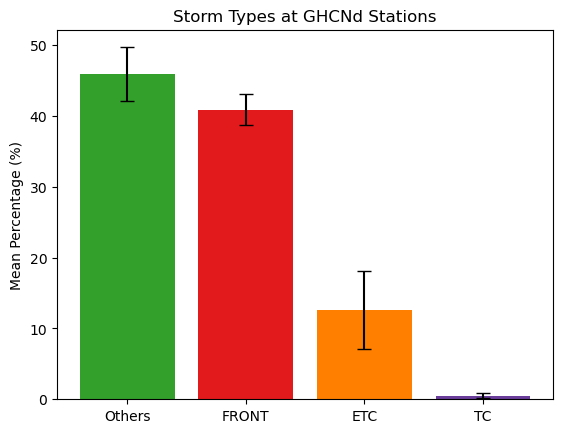

In [14]:
import matplotlib.pyplot as plt
order = means.sort_values(ascending=False).index
plt.bar(order, means[order], yerr=stds[order], capsize=5, color=[pie_colors[list(means.index).index(i)] for i in order])
plt.ylabel("Mean Percentage (%)")
plt.title("Storm Types at GHCNd Stations")
plt.show()